In [1]:
import os, math
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
from IPython.display import display, HTML

# Step 1. Scalability
We first run the scalability scenario to find the maximum number of clients for which the system remains balanced.

In [ ]:
# Variables that need to be set
workload = "pps"
scenario = "scalability"
trial_tag = "mh_50_mp_50"
database = "Detock"

base_dir = f"../../data/{workload}/{scenario}/{trial_tag}/{database}"

Clients: 1, Throughput per machine: {'0-0': 22.533333333333335, '1-0': 23.433333333333334}
Clients: 10, Throughput per machine: {'0-0': 239.38333333333333, '1-0': 238.08333333333334}
Clients: 100, Throughput per machine: {'0-0': 2259.2833333333333, '1-0': 2251.133333333333}
Clients: 500, Throughput per machine: {'0-0': 9950.65, '1-0': 9957.25}
Clients: 1000, Throughput per machine: {'0-0': 18141.416666666668, '1-0': 18278.366666666665}
Clients: 1250, Throughput per machine: {'0-0': 21417.433333333334, '1-0': 22073.566666666666}
Clients: 1500, Throughput per machine: {'0-0': 23149.733333333334, '1-0': 24854.366666666665}
Clients: 1750, Throughput per machine: {'0-0': 15515.016666666666, '1-0': 29028.283333333333}
Clients: 2000, Throughput per machine: {'0-0': 16719.416666666668, '1-0': 28803.666666666668}
Clients: 3000, Throughput per machine: {'0-0': 14833.316666666668, '1-0': 27315.5}
Clients: 4000, Throughput per machine: {'0-0': 10945.766666666666, '1-0': 27986.533333333333}
Clients

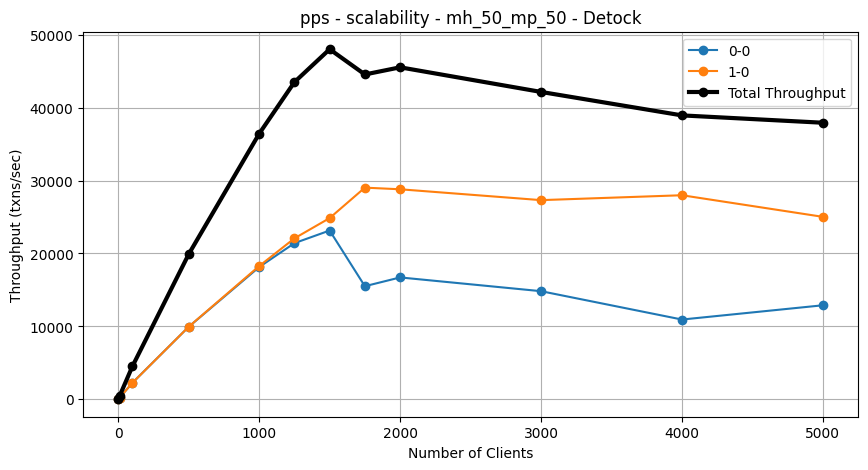

In [30]:
# Collect throughput data
throughput = defaultdict(dict)
for experiment in os.listdir(base_dir):
    client_num = int(experiment)
    for machine in os.listdir(f"{base_dir}/{experiment}/client"):
        if os.path.isdir(f"{base_dir}/{experiment}/client/{machine}"):
            metadata = pd.read_csv(f"{base_dir}/{experiment}/client/{machine}/metadata.csv")
            summary = pd.read_csv(f"{base_dir}/{experiment}/client/{machine}/summary.csv")

            duration = metadata["duration"].sum()
            throughput_per_machine = summary["committed"].sum() / duration
            throughput[client_num][machine] = throughput_per_machine
# Plot throughput vs number of clients (both general throughput and per-machine throughput)
plt.figure(figsize=(10, 5))
clients_nums = sorted(throughput.keys())
throughput_per_machine = defaultdict(list)
for clients_num in clients_nums:
    print(f"Clients: {clients_num}, Throughput per machine: {throughput[clients_num]}")
    for machine, tp in throughput[clients_num].items():
        throughput_per_machine[machine].append(tp)
for machine, tps in throughput_per_machine.items():
    plt.plot(clients_nums, tps, label=machine, marker='o')
total_throughputs = [sum(throughput[cn].values()) for cn in clients_nums]
plt.plot(clients_nums, total_throughputs, label="Total Throughput", marker='o', linewidth=3, color='black')
plt.xlabel("Number of Clients")
plt.ylabel("Throughput (txns/sec)")
plt.title(f"{workload} - {scenario} - {trial_tag} - {database}")
plt.legend()
plt.grid()
plt.show()

Percentile: 50
0-0 : [7.06, 6.17, 6.33, 39.42, 50.66, 55.7, 63.46, 116.6, 113.83, 119.02, 231.38, 304.54]
1-0 : [6.45, 6.12, 6.25, 38.46, 49.64, 52.65, 57.23, 56.41, 65.16, 103.61, 134.18, 184.79]
Percentile: 75
0-0 : [107.33, 105.99, 106.16, 106.21, 109.42, 112.02, 116.65, 184.16, 202.3, 366.2, 748.16, 675.79]
1-0 : [106.96, 106.0, 106.17, 105.96, 108.54, 110.19, 113.37, 112.89, 121.33, 160.78, 192.33, 242.39]
Percentile: 90
0-0 : [109.72, 108.24, 107.32, 108.84, 112.6, 116.01, 122.54, 224.27, 251.35, 440.73, 830.18, 929.56]
1-0 : [108.96, 108.14, 107.3, 108.44, 111.9, 113.89, 117.96, 116.8, 125.91, 164.93, 197.32, 256.07]
Percentile: 95
0-0 : [109.95, 108.57, 108.02, 109.78, 113.81, 117.66, 125.93, 237.29, 266.81, 493.19, 873.4, 1087.74]
1-0 : [109.14, 108.42, 107.9, 109.49, 113.2, 115.33, 119.79, 118.41, 128.03, 166.9, 200.19, 263.63]
Percentile: 99
0-0 : [110.51, 108.89, 109.15, 111.4, 116.13, 120.92, 159.93, 429.35, 354.28, 610.62, 950.22, 1266.55]
1-0 : [109.45, 108.91, 108.93, 1

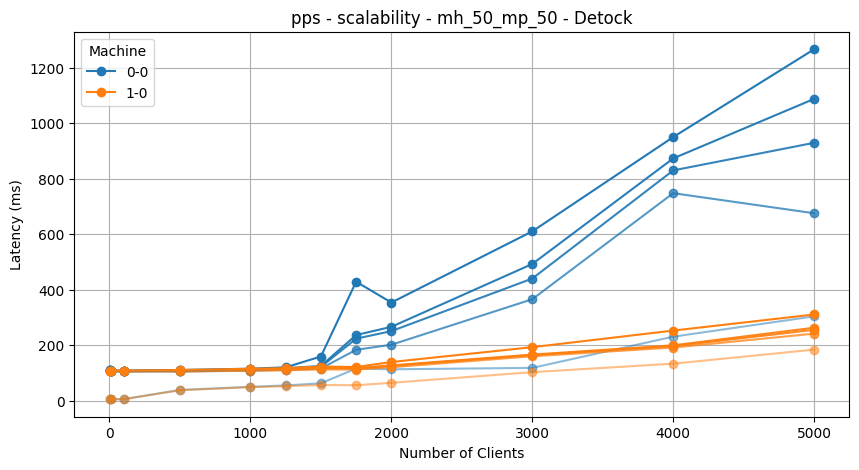

In [43]:
# Variables that need to be set for latency analysis
percentiles = [50, 75, 90, 95, 99]

# Collect latency data
latencies = defaultdict(dict)
for experiment in os.listdir(base_dir):
    client_num = int(experiment)
    for machine in os.listdir(f"{base_dir}/{experiment}/client"):
        if os.path.isdir(f"{base_dir}/{experiment}/client/{machine}"):
            txns = pd.read_csv(f"{base_dir}/{experiment}/client/{machine}/transactions.csv")
            txns["sent_at"] = pd.to_numeric(txns["sent_at"], errors="coerce")
            txns["received_at"] = pd.to_numeric(txns["received_at"], errors="coerce")
            txns["aborted"] = txns["received_at"].isna() | (txns["received_at"] < txns["sent_at"])
            txns = txns[~txns["aborted"]].copy()
            txns["latency_ms"] = (txns["received_at"] - txns["sent_at"]) / 1e6
            txns = txns.sort_values("sent_at").reset_index(drop=True)
            latencies[client_num][machine] = txns["latency_ms"].values
# Plot latency percentiles vs number of clients (per machine)
plt.figure(figsize=(10, 5))
clients_nums = sorted(latencies.keys())
percentiles_per_machine = {}
for perc in percentiles:
    percentiles_per_machine[perc] = defaultdict(list)
    for clients_num in clients_nums:
        for machine, lat_array in latencies[clients_num].items():
            perc_value = np.percentile(lat_array, perc)
            percentiles_per_machine[perc][machine].append(perc_value)
    print(f"Percentile: {perc}")
    for machine, perc_values in percentiles_per_machine[perc].items():
        print(machine, ":", [round(v, 2) for v in perc_values])
machines = list(next(iter(percentiles_per_machine.values())).keys())
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
machine_color = {m: cycle[i % len(cycle)] for i, m in enumerate(machines)}
for perc in percentiles:
    for machine in machines:
        y = percentiles_per_machine[perc][machine]
        label = machine if perc == max(percentiles) else None
        alpha = perc / 100.0
        plt.plot(clients_nums, y, color=machine_color[machine], alpha=alpha, label=label,marker='o')
plt.xlabel("Number of Clients")
plt.ylabel("Latency (ms)")
plt.title(f"{workload} - {scenario} - {trial_tag} - {database}")
plt.legend(title="Machine")
plt.grid(True)
plt.show()


# Step 2. Sunflower
Now, that we get the appropriate number of clients, we'll vary the number per region.

In [45]:
# Variables that need to be set
workload = "pps"
scenario = "sunflower"
trial_tag = "finegrained"
database = "Detock"

base_dir = f"../../data/{workload}/{scenario}/{trial_tag}/{database}"

Clients: (700, 2300), Throughput per machine: {'0-0': 12137.616666666667, '1-0': 26390.083333333332}
Clients: (800, 2200), Throughput per machine: {'0-0': 14034.133333333333, '1-0': 26849.85}
Clients: (900, 2100), Throughput per machine: {'0-0': 16161.466666666667, '1-0': 27216.933333333334}
Clients: (1000, 2000), Throughput per machine: {'0-0': 17603.1, '1-0': 26680.35}
Clients: (1100, 1900), Throughput per machine: {'0-0': 18487.816666666666, '1-0': 26902.883333333335}
Clients: (1200, 1800), Throughput per machine: {'0-0': 19128.233333333334, '1-0': 26263.05}
Clients: (1300, 1700), Throughput per machine: {'0-0': 20836.016666666666, '1-0': 26672.55}
Clients: (1400, 1600), Throughput per machine: {'0-0': 18568.1, '1-0': 24938.45}
Clients: (1500, 1500), Throughput per machine: {'0-0': 25003.3, '1-0': 23784.916666666668}
Clients: (1600, 1400), Throughput per machine: {'0-0': 26162.283333333333, '1-0': 22611.566666666666}
Clients: (1700, 1300), Throughput per machine: {'0-0': 27002.4, '1

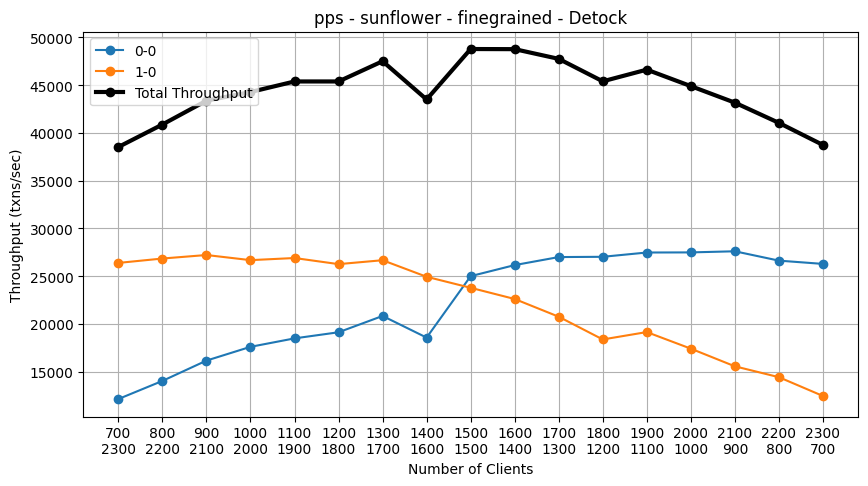

In [58]:
# Collect throughput data
throughput = defaultdict(dict)
for experiment in os.listdir(base_dir):
    client_num = (int(experiment.split(",")[0]), int(experiment.split(",")[1]))
    for machine in os.listdir(f"{base_dir}/{experiment}/client"):
        if os.path.isdir(f"{base_dir}/{experiment}/client/{machine}"):
            metadata = pd.read_csv(f"{base_dir}/{experiment}/client/{machine}/metadata.csv")
            summary = pd.read_csv(f"{base_dir}/{experiment}/client/{machine}/summary.csv")

            duration = metadata["duration"].sum()
            throughput_per_machine = summary["committed"].sum() / duration
            throughput[client_num][machine] = throughput_per_machine
# Plot throughput vs number of clients (both general throughput and per-machine throughput)
plt.figure(figsize=(10, 5))
clients_nums = sorted(throughput.keys())
x = np.arange(len(clients_nums))
throughput_per_machine = defaultdict(list)
for clients_num in clients_nums:
    print(f"Clients: {clients_num}, Throughput per machine: {throughput[clients_num]}")
    for machine, tp in throughput[clients_num].items():
        throughput_per_machine[machine].append(tp)
for machine, tps in throughput_per_machine.items():
    plt.plot(x, tps, label=machine, marker='o')
total_throughputs = [sum(throughput[cn].values()) for cn in clients_nums]
plt.plot(x, total_throughputs, label="Total Throughput", marker='o', linewidth=3, color='black')
plt.xlabel("Number of Clients")
plt.xticks(x, [f"{cn[0]}\n{cn[1]}" for cn in clients_nums])
plt.ylabel("Throughput (txns/sec)")
plt.title(f"{workload} - {scenario} - {trial_tag} - {database}")
plt.legend(loc='upper left')
plt.grid()
plt.show()